## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import janitor
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
import warnings

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
warnings.simplefilter(action="ignore", category=DeprecationWarning)

In [4]:
df = pd.read_csv(r"C:\Users\shiri\OneDrive\Documents\Python\ml-projects\exchange-rates-forecasting\data\processed\model_data.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6285 entries, 0 to 6284
Columns: 385 entries, Date to day_lag_30_roll_std_7_ema_7_ema_7
dtypes: float64(384), object(1)
memory usage: 18.5+ MB


In [6]:
df.shape

(6285, 385)

In [7]:
df.columns

Index(['Date', 'INR', 'AUD', 'EUR', 'JPY', 'GBP', 'year', 'month', 'day',
       'INR_lag_1',
       ...
       'month_lag_7_roll_mean_7_ema_7_ema_7',
       'month_lag_7_roll_std_7_ema_7_ema_7',
       'month_lag_30_roll_mean_7_ema_7_ema_7',
       'month_lag_30_roll_std_7_ema_7_ema_7',
       'day_lag_1_roll_mean_7_ema_7_ema_7', 'day_lag_1_roll_std_7_ema_7_ema_7',
       'day_lag_7_roll_mean_7_ema_7_ema_7', 'day_lag_7_roll_std_7_ema_7_ema_7',
       'day_lag_30_roll_mean_7_ema_7_ema_7',
       'day_lag_30_roll_std_7_ema_7_ema_7'],
      dtype='object', length=385)

In [8]:
df.head()

,Date,INR,AUD,EUR,JPY,GBP,year,month,day,INR_lag_1,...,month_lag_7_roll_mean_7_ema_7_ema_7,month_lag_7_roll_std_7_ema_7_ema_7,month_lag_30_roll_mean_7_ema_7_ema_7,month_lag_30_roll_std_7_ema_7_ema_7,day_lag_1_roll_mean_7_ema_7_ema_7,day_lag_1_roll_std_7_ema_7_ema_7,day_lag_7_roll_mean_7_ema_7_ema_7,day_lag_7_roll_std_7_ema_7_ema_7,day_lag_30_roll_mean_7_ema_7_ema_7,day_lag_30_roll_std_7_ema_7_ema_7
0,2000-02-23,-0.027888,-0.801120,0.647815,-2.209306,0.071586,-1.641867,-1.313718,0.837859,0.031963,...,-1.522057,-0.080472,-1.711451,-0.536732,-1.099570,-0.725234,-1.022153,0.958521,-2.662717,-1.539873
1,2000-02-24,-0.027888,-0.092456,-2.397274,1.404008,-0.844374,-1.641867,-1.313718,0.952347,-0.027898,...,-1.500826,-0.144182,-1.711451,-0.536732,-0.858630,-0.886997,-1.261506,0.603255,-2.635382,-1.539873
2,2000-02-25,0.091805,-0.634949,-1.198975,-0.559749,-0.684617,-1.641867,-1.313718,1.066835,-0.027898,...,-1.482602,-0.204574,-1.711451,-0.536732,-0.574489,-1.018891,-1.398720,0.269401,-2.567047,-1.545315
3,2000-02-28,-0.087727,-0.805191,-2.453664,-3.073359,-0.426122,-1.641867,-1.313718,1.410300,0.091785,...,-1.467209,-0.259324,-1.711451,-0.536732,-0.256458,-1.131184,-1.442543,-0.031543,-2.446511,-1.546859
4,2000-02-29,-0.087741,0.132323,1.056647,2.000990,0.321105,-1.641867,-1.313718,1.524788,-0.087733,...,-1.454370,-0.307479,-1.711451,-0.536732,0.094187,-1.218813,-1.403734,-0.300607,-2.270737,-1.552733


## Data Processing

In [9]:
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index
df.set_index('Date', inplace=True)

# sort the index
df.sort_index(inplace=True)

#### Create Sequences

In [10]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])  # next time step
    return np.array(X), np.array(y)

seq_length = 10  
X, y = create_sequences(df.values, seq_length)  


#### Train-Test Split

In [11]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


#### Convert to Tensors

In [12]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [13]:
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)


X_train: torch.Size([5020, 10, 384])
y_train: torch.Size([5020, 384])
X_test: torch.Size([1255, 10, 384])
y_test: torch.Size([1255, 384])


#### Dataset and DataLoader

In [14]:
class ExchangeDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64

train_dataset = ExchangeDataset(X_train_tensor, y_train_tensor)
test_dataset = ExchangeDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


## Models

### 1. Single Layer RNN

In [37]:
class SingleLayerRNN(nn.Module):
    def __init__(self, input_size, hidden_size=64, output_size=1, dropout=0.2):
        super(SingleLayerRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])  # last time step + dropout
        out = self.fc(out)
        return out

In [38]:
input_size = X_train.shape[2]  # Features per time step
hidden_size = 64
output_size = y_train.shape[1]  # Number of target values

model = SingleLayerRNN(input_size, hidden_size, output_size)

In [39]:
def train_model(model, train_loader, test_loader, optimizer_name='Adam', scheduler_name='StepLR',
                num_epochs=100, lr=0.001, patience=10):
    
    criterion = nn.MSELoss()

    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError("Optimizer must be 'Adam' or 'SGD'")
    
    if scheduler_name == 'StepLR':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
    elif scheduler_name == 'ReduceLROnPlateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=True)
    else:
        scheduler = None
    
    train_losses, test_losses = [], []
    train_r2s, test_r2s = [], []

    best_test_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0
        y_true_train = []
        y_pred_train = []

        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
            y_true_train.append(yb.detach().cpu())
            y_pred_train.append(pred.detach().cpu())

        train_loss = running_train_loss / len(train_loader)
        train_losses.append(train_loss)
        
        y_true_train = torch.cat(y_true_train).numpy()
        y_pred_train = torch.cat(y_pred_train).numpy()
        train_r2 = r2_score(y_true_train, y_pred_train)
        train_r2s.append(train_r2)

        # Validation
        model.eval()
        running_test_loss = 0
        y_true_test = []
        y_pred_test = []

        with torch.no_grad():
            for xb, yb in test_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                running_test_loss += loss.item()
                y_true_test.append(yb.detach().cpu())
                y_pred_test.append(pred.detach().cpu())

        test_loss = running_test_loss / len(test_loader)
        test_losses.append(test_loss)

        y_true_test = torch.cat(y_true_test).numpy()
        y_pred_test = torch.cat(y_pred_test).numpy()
        test_r2 = r2_score(y_true_test, y_pred_test)
        test_r2s.append(test_r2)

        # Step the scheduler
        if scheduler_name == 'StepLR':
            scheduler.step()
        elif scheduler_name == 'ReduceLROnPlateau':
            scheduler.step(test_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
              f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")

        # Early stopping
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            epochs_no_improve = 0
            best_model_wts = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered!")
                break

    model.load_state_dict(best_model_wts)
    return train_losses, test_losses, train_r2s, test_r2s

In [42]:
# Train the model 
train_losses, test_losses, train_r2s, test_r2s = train_model(
    model, train_loader, test_loader,
    optimizer_name='Adam',
    scheduler_name='StepLR',
    num_epochs=30,
    lr=0.001,
    patience=10
)

Epoch [1/30] | Train Loss: 0.2289 | Test Loss: 0.1213 | Train R2: 0.7791 | Test R2: 0.7435
Epoch [2/30] | Train Loss: 0.2253 | Test Loss: 0.1208 | Train R2: 0.7824 | Test R2: 0.7128
Epoch [3/30] | Train Loss: 0.2274 | Test Loss: 0.1218 | Train R2: 0.7805 | Test R2: 0.6952
Epoch [4/30] | Train Loss: 0.2268 | Test Loss: 0.1199 | Train R2: 0.7809 | Test R2: 0.7168
Epoch [5/30] | Train Loss: 0.2272 | Test Loss: 0.1191 | Train R2: 0.7806 | Test R2: 0.7413
Epoch [6/30] | Train Loss: 0.2261 | Test Loss: 0.1210 | Train R2: 0.7817 | Test R2: 0.7067
Epoch [7/30] | Train Loss: 0.2267 | Test Loss: 0.1202 | Train R2: 0.7812 | Test R2: 0.6971
Epoch [8/30] | Train Loss: 0.2256 | Test Loss: 0.1192 | Train R2: 0.7821 | Test R2: 0.7374
Epoch [9/30] | Train Loss: 0.2282 | Test Loss: 0.1194 | Train R2: 0.7796 | Test R2: 0.7284
Epoch [10/30] | Train Loss: 0.2256 | Test Loss: 0.1204 | Train R2: 0.7823 | Test R2: 0.6899
Epoch [11/30] | Train Loss: 0.2263 | Test Loss: 0.1211 | Train R2: 0.7814 | Test R2: 0.67

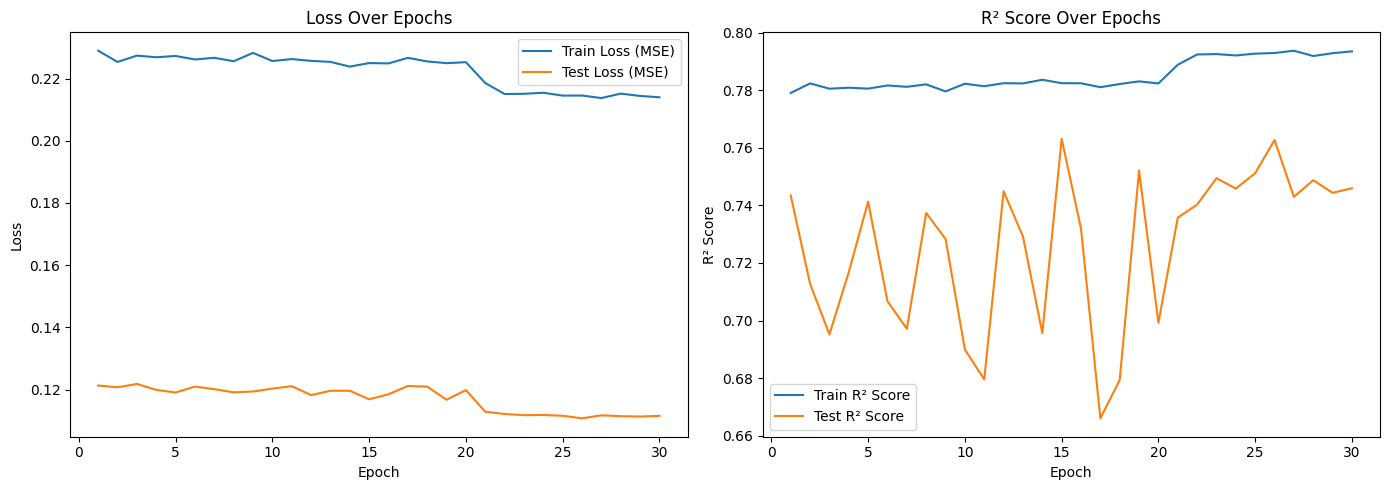

In [43]:
def plot_metrics(train_losses, test_losses, train_r2s, test_r2s):
    epochs = range(1, len(train_losses)+1)

    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss (MSE)")
    plt.plot(epochs, test_losses, label="Test Loss (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Over Epochs")
    plt.legend()
    plt.grid(False)

    # R² Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_r2s, label="Train R² Score")
    plt.plot(epochs, test_r2s, label="Test R² Score")
    plt.xlabel("Epoch")
    plt.ylabel("R² Score")
    plt.title("R² Score Over Epochs")
    plt.legend()
    plt.grid(False)

    plt.tight_layout()
    plt.show()

plot_metrics(train_losses, test_losses, train_r2s, test_r2s)

### 2. Multi Layer RNN

In [46]:
class MultiLayerRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.2):
        super(MultiLayerRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [47]:
model_multi_rnn = MultiLayerRNN(input_size, hidden_size, output_size, num_layers=2)

In [48]:
train_losses, test_losses, train_r2s, test_r2s = train_model(
    model_multi_rnn, train_loader, test_loader, num_epochs=30, lr=0.001
)

Epoch [1/30] | Train Loss: 0.7933 | Test Loss: 0.4683 | Train R2: 0.2181 | Test R2: -0.2326
Epoch [2/30] | Train Loss: 0.5387 | Test Loss: 0.3804 | Train R2: 0.4790 | Test R2: -0.0307
Epoch [3/30] | Train Loss: 0.4635 | Test Loss: 0.3326 | Train R2: 0.5517 | Test R2: 0.1430
Epoch [4/30] | Train Loss: 0.4215 | Test Loss: 0.3032 | Train R2: 0.5922 | Test R2: 0.1955
Epoch [5/30] | Train Loss: 0.3939 | Test Loss: 0.2799 | Train R2: 0.6199 | Test R2: 0.2828
Epoch [6/30] | Train Loss: 0.3761 | Test Loss: 0.2687 | Train R2: 0.6369 | Test R2: 0.3216
Epoch [7/30] | Train Loss: 0.3601 | Test Loss: 0.2557 | Train R2: 0.6525 | Test R2: 0.2914
Epoch [8/30] | Train Loss: 0.3499 | Test Loss: 0.2455 | Train R2: 0.6626 | Test R2: 0.3235
Epoch [9/30] | Train Loss: 0.3428 | Test Loss: 0.2393 | Train R2: 0.6692 | Test R2: 0.3481
Epoch [10/30] | Train Loss: 0.3339 | Test Loss: 0.2303 | Train R2: 0.6781 | Test R2: 0.3991
Epoch [11/30] | Train Loss: 0.3258 | Test Loss: 0.2287 | Train R2: 0.6859 | Test R2: 0.

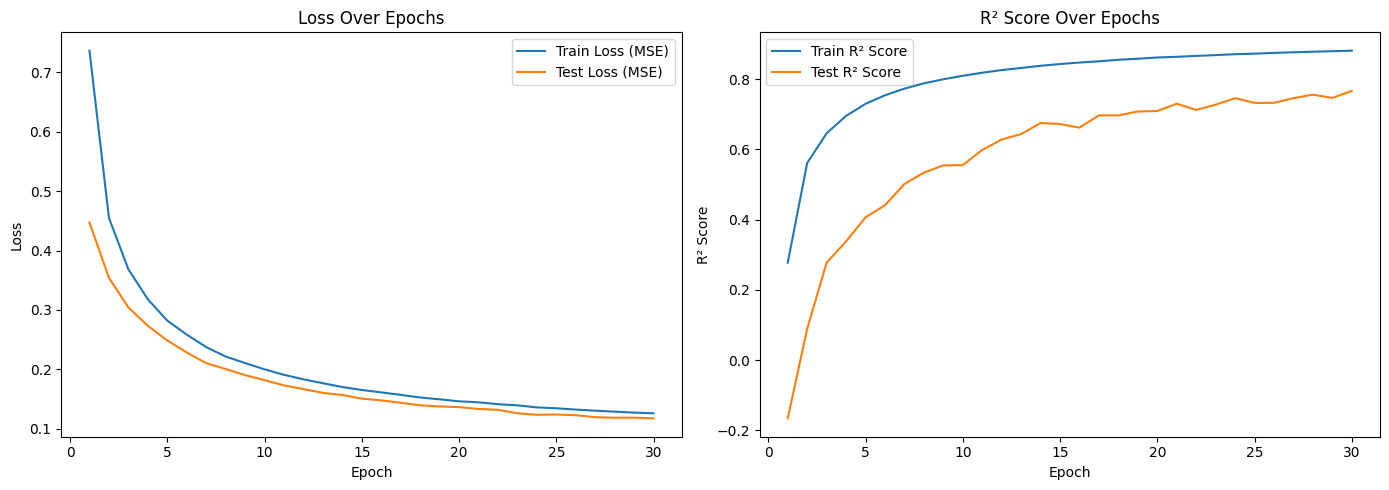

In [26]:
plot_metrics(train_losses, test_losses, train_r2s, test_r2s)

### 3. Bidirectional RNN

In [27]:
class SingleLayerBidirectionalRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SingleLayerBidirectionalRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, output_size)  # *2 for bidirectional

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # last time step output
        return out

In [28]:
input_size = X_train.shape[2]  # features
hidden_size = 64
output_size = y_train.shape[1]  # targets

model = SingleLayerBidirectionalRNN(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [29]:
train_losses, test_losses, train_r2s, test_r2s = train_model(model, train_loader, test_loader, num_epochs=30, lr=0.001)


Epoch [1/30] | Train Loss: 0.5826 | Test Loss: 0.2860 | Train R²: 0.4308 | Test R²: 0.3398
Epoch [2/30] | Train Loss: 0.2851 | Test Loss: 0.1973 | Train R²: 0.7254 | Test R²: 0.5720
Epoch [3/30] | Train Loss: 0.2135 | Test Loss: 0.1594 | Train R²: 0.7959 | Test R²: 0.6725
Epoch [4/30] | Train Loss: 0.1785 | Test Loss: 0.1395 | Train R²: 0.8294 | Test R²: 0.7225
Epoch [5/30] | Train Loss: 0.1587 | Test Loss: 0.1271 | Train R²: 0.8488 | Test R²: 0.7412
Epoch [6/30] | Train Loss: 0.1454 | Test Loss: 0.1191 | Train R²: 0.8617 | Test R²: 0.7666
Epoch [7/30] | Train Loss: 0.1370 | Test Loss: 0.1121 | Train R²: 0.8704 | Test R²: 0.7774
Epoch [8/30] | Train Loss: 0.1299 | Test Loss: 0.1078 | Train R²: 0.8771 | Test R²: 0.7979
Epoch [9/30] | Train Loss: 0.1244 | Test Loss: 0.1046 | Train R²: 0.8823 | Test R²: 0.7990
Epoch [10/30] | Train Loss: 0.1204 | Test Loss: 0.1024 | Train R²: 0.8860 | Test R²: 0.8089
Epoch [11/30] | Train Loss: 0.1163 | Test Loss: 0.0988 | Train R²: 0.8896 | Test R²: 0.81

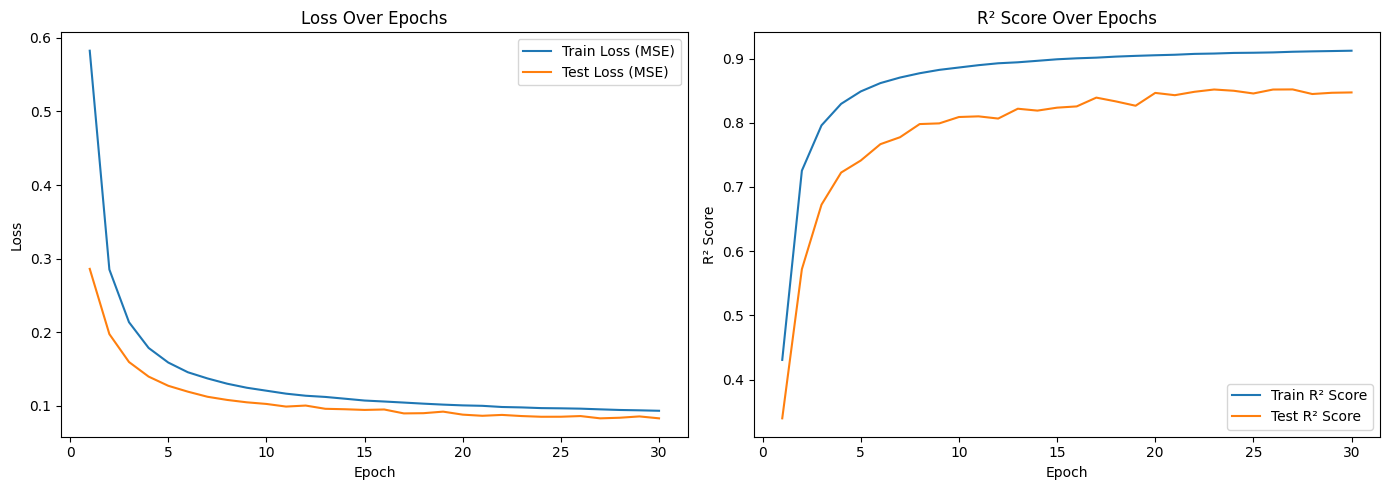

In [30]:
plot_metrics(train_losses, test_losses, train_r2s, test_r2s)

### 4. LSTM Model

In [31]:
class SingleLayerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SingleLayerLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = self.fc(out[:, -1, :])  # last time step
        return out

In [32]:
input_size = X_train.shape[2]  # Number of features per time step
hidden_size = 64
output_size = y_train.shape[1]  # Number of output targets

model = SingleLayerLSTM(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [33]:
train_losses, test_losses, train_r2s, test_r2s = train_model(model, train_loader, test_loader, num_epochs=30, lr=0.001)

Epoch [1/30] | Train Loss: 0.7890 | Test Loss: 0.7198 | Train R²: 0.2225 | Test R²: -2.8321
Epoch [2/30] | Train Loss: 0.4645 | Test Loss: 0.4711 | Train R²: 0.5496 | Test R²: -0.9320
Epoch [3/30] | Train Loss: 0.3515 | Test Loss: 0.3746 | Train R²: 0.6634 | Test R²: -0.3192
Epoch [4/30] | Train Loss: 0.2922 | Test Loss: 0.3195 | Train R²: 0.7201 | Test R²: -0.0222
Epoch [5/30] | Train Loss: 0.2559 | Test Loss: 0.2991 | Train R²: 0.7557 | Test R²: 0.0714
Epoch [6/30] | Train Loss: 0.2294 | Test Loss: 0.2816 | Train R²: 0.7808 | Test R²: 0.0753
Epoch [7/30] | Train Loss: 0.2105 | Test Loss: 0.2711 | Train R²: 0.7990 | Test R²: 0.1192
Epoch [8/30] | Train Loss: 0.1969 | Test Loss: 0.2502 | Train R²: 0.8127 | Test R²: 0.2233
Epoch [9/30] | Train Loss: 0.1844 | Test Loss: 0.2433 | Train R²: 0.8242 | Test R²: 0.2238
Epoch [10/30] | Train Loss: 0.1748 | Test Loss: 0.2402 | Train R²: 0.8335 | Test R²: 0.2332
Epoch [11/30] | Train Loss: 0.1669 | Test Loss: 0.2183 | Train R²: 0.8410 | Test R²: 

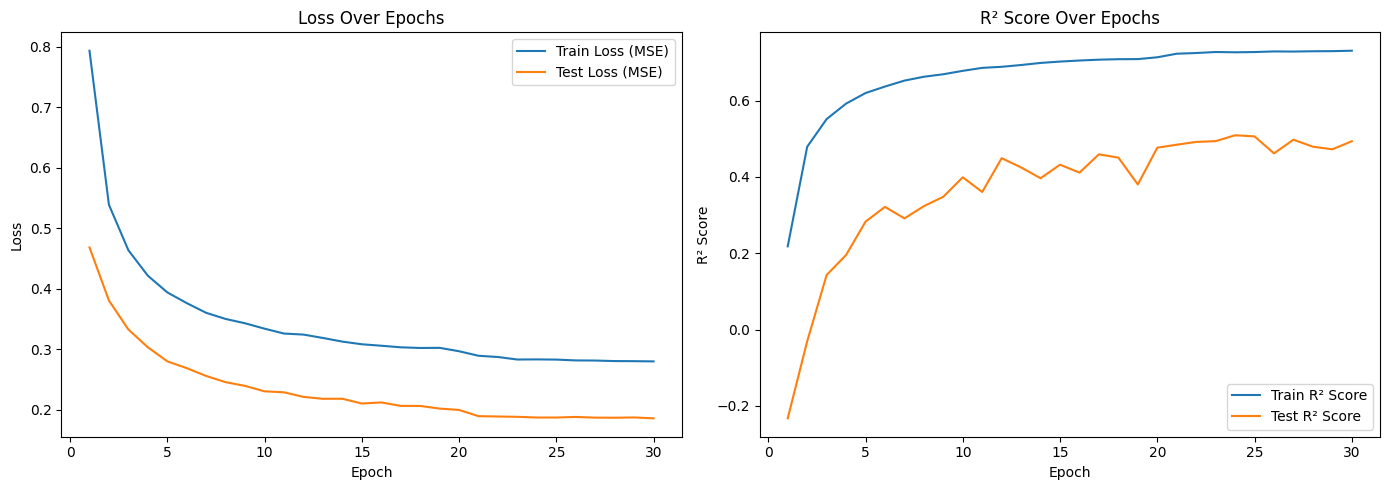

In [49]:
plot_metrics(train_losses, test_losses, train_r2s, test_r2s)